<a href="https://colab.research.google.com/github/snyderk016/Machine-Learning/blob/main/CharacterizingLiMaterials.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The goal of this project is to see if it is possible to classify proposed lithium ion battery materials found using DFT as stable or unstable based off of only two features. This dataset includes number of elements, contains transition metal (as true/false), formation energy per atom (eV), energy per atom (eV), band gap (eV), is a semiconductor (as true/false), density (in g/cm3), volume (cubic Angstroms), and elemental composition. Formation energy per atom will be used to categorize materials as stable or unstable, with formation energy per atom <0 classified as stable, and formation energy per atom >0 being classified as unstable. Three decision tree models  Random Forest, Gradient Boosting, and XG Boost, both with and without hyperparameter optimization, will be used to find the two most important features. If possible and meaningful, a decision boundary will be used to classify materials as stable or unstable based on two features. The distribution of stable and unstable points across the two features will then be analylized for meaningful conclusions.

Link to dataset is here: (https://www.kaggle.com/datasets/allanwandia/material-science/data)

Load Dataset:

In [ ]:
import pandas as pd

df = pd.read_csv('li_battery_dataset.csv')
df.head(10)

/tmp/ipykernel_10633/3245455706.py:3: DtypeWarning: Columns (13,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('li_battery_dataset.csv')


,material_id,formula_pretty,n_elements,contains_transition_metal,formation_energy_per_atom,energy_per_atom,band_gap,is_semiconductor,density,volume,elements,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,mp-1232999,LiO8,2,False,1.720359,0.654797,-0.765226,False,-1.181862,-0.911997,"['Li', 'O']",NaN,NaN,elements range,NaN,denisty range,NaN,nad gap range
1,mp-1236127,LiO8,2,False,1.719137,0.654475,-0.808019,False,-1.237528,-0.897719,"['Li', 'O']",NaN,NaN,8,NaN,10.32946234,NaN,5.033427949
2,mp-1546006,LiS4,2,False,1.902530,0.036938,0.626478,True,-2.352166,4.289055,"['Li', 'S']",NaN,NaN,2,NaN,-2.477204089,NaN,-0.868212862
3,mp-995393,LiS4,2,False,1.499043,0.862733,0.620655,True,-2.367226,4.875701,"['Li', 'S']",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mp-569073,LiSn,2,False,1.813196,1.158327,-0.868213,False,0.894787,-0.882882,"['Li', 'Sn']",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,mp-1001825,LiBe,2,False,2.355390,1.340512,-0.868213,False,-1.715112,-1.109235,"['Be', 'Li']",NaN,NaN,e per atom range,NaN,e range,NaN,NaN
6,mp-2475638,LiBe,2,False,2.350128,1.339125,-0.868213,False,-1.734839,-1.105950,"['Be', 'Li']",NaN,NaN,2.055498014,NaN,7.952180218,NaN,NaN
7,mp-1057216,LiS,2,False,1.208599,0.980194,-0.868213,False,-1.217245,-1.141286,"['Li', 'S']",NaN,NaN,-16.62359082,NaN,-2.333873105,NaN,NaN
8,mp-1103120,LiB11,2,False,2.890774,0.289526,-0.868213,False,-0.819361,-0.999194,"['B', 'Li']",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,mp-1101854,LiB11,2,False,2.980760,0.313258,-0.868213,False,-0.832948,-0.997257,"['B', 'Li']",NaN,NaN,NaN,NaN,NaN,NaN,NaN


Two of the features of interest orignally contain non-numerical data as boolean true/false values. We will convert them to integers with 0 = false and 1 = true.

In [ ]:
#change true/false values to 0s and 1s
df['contains_transition_metal'] = df['contains_transition_metal'].astype(int)
df['is_semiconductor'] = df['is_semiconductor'].astype(int)

display(df.head())

,material_id,formula_pretty,n_elements,contains_transition_metal,formation_energy_per_atom,energy_per_atom,band_gap,is_semiconductor,density,volume,elements,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17
0,mp-1232999,LiO8,2,0,1.720359,0.654797,-0.765226,0,-1.181862,-0.911997,"['Li', 'O']",NaN,NaN,elements range,NaN,denisty range,NaN,nad gap range
1,mp-1236127,LiO8,2,0,1.719137,0.654475,-0.808019,0,-1.237528,-0.897719,"['Li', 'O']",NaN,NaN,8,NaN,10.32946234,NaN,5.033427949
2,mp-1546006,LiS4,2,0,1.902530,0.036938,0.626478,1,-2.352166,4.289055,"['Li', 'S']",NaN,NaN,2,NaN,-2.477204089,NaN,-0.868212862
3,mp-995393,LiS4,2,0,1.499043,0.862733,0.620655,1,-2.367226,4.875701,"['Li', 'S']",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mp-569073,LiSn,2,0,1.813196,1.158327,-0.868213,0,0.894787,-0.882882,"['Li', 'Sn']",NaN,NaN,NaN,NaN,NaN,NaN,NaN


We will assume that a formation energy per atom that is <0 is a likely stable battery composition and will be labeled as such. We will also assume that a formation energy per atom that is >0 is likely unstable, and will be labeled as such.

In [ ]:
#add labels to the data

df["stability"] = (
    df["formation_energy_per_atom"] < 0
).astype(int)

Materials that are "stable will be labeled as 1. Materials that are unstable will be labeled as 0.

We will check to make sure our labeling system worked, we can see that materials with formation energy per atom greater than zero are labeled as 0/unstable, and that materials with formation energy per atom less than zero are labeled as 1/stable.

In [ ]:
display(df.head(10))

,material_id,formula_pretty,n_elements,contains_transition_metal,formation_energy_per_atom,energy_per_atom,band_gap,is_semiconductor,density,volume,elements,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,stability
0,mp-1232999,LiO8,2,0,1.720359,0.654797,-0.765226,0,-1.181862,-0.911997,"['Li', 'O']",NaN,NaN,elements range,NaN,denisty range,NaN,nad gap range,0
1,mp-1236127,LiO8,2,0,1.719137,0.654475,-0.808019,0,-1.237528,-0.897719,"['Li', 'O']",NaN,NaN,8,NaN,10.32946234,NaN,5.033427949,0
2,mp-1546006,LiS4,2,0,1.902530,0.036938,0.626478,1,-2.352166,4.289055,"['Li', 'S']",NaN,NaN,2,NaN,-2.477204089,NaN,-0.868212862,0
3,mp-995393,LiS4,2,0,1.499043,0.862733,0.620655,1,-2.367226,4.875701,"['Li', 'S']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,mp-569073,LiSn,2,0,1.813196,1.158327,-0.868213,0,0.894787,-0.882882,"['Li', 'Sn']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,mp-1001825,LiBe,2,0,2.355390,1.340512,-0.868213,0,-1.715112,-1.109235,"['Be', 'Li']",NaN,NaN,e per atom range,NaN,e range,NaN,NaN,0
6,mp-2475638,LiBe,2,0,2.350128,1.339125,-0.868213,0,-1.734839,-1.105950,"['Be', 'Li']",NaN,NaN,2.055498014,NaN,7.952180218,NaN,NaN,0
7,mp-1057216,LiS,2,0,1.208599,0.980194,-0.868213,0,-1.217245,-1.141286,"['Li', 'S']",NaN,NaN,-16.62359082,NaN,-2.333873105,NaN,NaN,0
8,mp-1103120,LiB11,2,0,2.890774,0.289526,-0.868213,0,-0.819361,-0.999194,"['B', 'Li']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9,mp-1101854,LiB11,2,0,2.980760,0.313258,-0.868213,0,-0.832948,-0.997257,"['B', 'Li']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
display(df.tail(10))

,material_id,formula_pretty,n_elements,contains_transition_metal,formation_energy_per_atom,energy_per_atom,band_gap,is_semiconductor,density,volume,elements,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,stability
86978,mp-569841,Ba19Li44,2,0,2.178516,1.558542,-0.868213,0,-0.982401,11.010803,"['Ba', 'Li']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
86979,mp-1177487,Li47(CoO4)8,3,1,0.064409,0.538152,-0.307306,0,-0.736817,1.132520,"['Co', 'Li', 'O']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
86980,mp-850945,Li47(NiO4)8,3,1,0.122604,0.589605,-0.145751,0,-0.720825,1.107879,"['Li', 'Ni', 'O']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
86981,mp-532427,Li47Mn5As19,3,1,1.514878,1.021806,-0.868213,0,-0.434773,1.892733,"['As', 'Li', 'Mn']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
86982,mp-532007,Li47Cu7N18,3,0,1.679342,0.561452,-0.868213,0,-1.086518,1.069187,"['Cu', 'Li', 'N']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
86983,mp-1001069,Li48P16S61,3,0,0.890142,0.773741,0.686062,1,-1.344163,6.430479,"['Li', 'P', 'S']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
86984,mp-676829,Li49Cu8N19,3,0,1.686606,0.543630,-0.868213,0,-1.028787,1.177355,"['Cu', 'Li', 'N']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
86985,mp-722623,Li66Be24H35,3,0,2.117250,1.320546,-0.868213,0,-1.966237,2.955622,"['Be', 'H', 'Li']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
86986,mp-647275,Ba39Li80N9,3,0,2.097097,1.405895,-0.868213,0,-0.814328,10.189519,"['Ba', 'Li', 'N']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
86987,mp-1185524,Li95Mn16O64,3,1,-0.079223,0.449108,-0.868213,0,-0.839734,3.685992,"['Li', 'Mn', 'O']",NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


Now that stability labels have been added, we can try to use Random Forest to find which features correlate to stability. The features of interest are contains transition metal, energy per atom, band gap, semiconductor character, density, and volume.

Note: I am excluding formation energy per atom and number of atoms. Formation energy per atom was used to calculate stability, and excluding it will prevent data leakage. Number of atoms is too closely related to formation energy per atom, with a scalar-like relationship, so it will also be excluded to prevent data leakage.

In [ ]:
#start by putting five features into features df
features = ['contains_transition_metal', 'energy_per_atom','band_gap', 'is_semiconductor', 'density', 'volume']

#convert data into dataframes and drop NANs
#this will ensure that the atoms label column is not included as it is non numerical
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=features, inplace=True)

#set up X and y values for training and testing of RF
X = df[features]
y= df['stability']

In [ ]:
#split data into 80% training data and 20% test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#start training random forest
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=10,
                                 n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)


RandomForestClassifier(max_leaf_nodes=10, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_train_pred = rnd_clf.predict(X_train)

train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print(f"Training Precision: {train_precision:.4f}")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1 Score: {train_f1:.4f}")

Training Precision: 0.8772
Training Accuracy: 0.8770
Training F1 Score: 0.8754


In [ ]:
#evaluate RF on test data
y_pred = rnd_clf.predict(X_test)

In [ ]:
importances = rnd_clf.feature_importances_

print(importances)

[0.00492806 0.47398317 0.17777051 0.06647724 0.20933298 0.06750804]


After training the Random Forest, we can find feature importance.

The features listed in order of importance are:

1. Energy per atom = 0.4740
2. Density = 0.2093
3. Band Gap = 0.1778
4. Volume = 0.0675
5. Semiconductor characteristics = 0.0664
6. Contains transition metal = 0.0049


The top two most important features from this Random Forest Model are energy per atom and density.

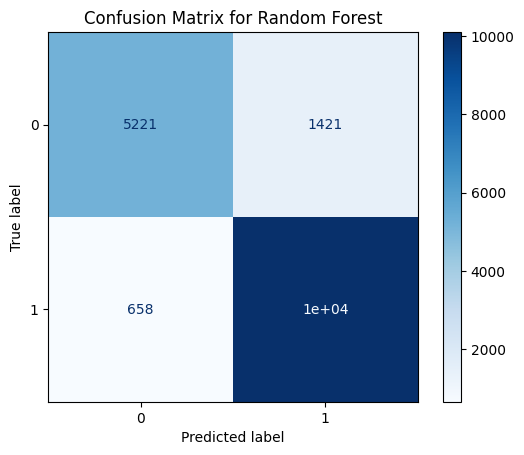

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rnd_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rnd_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest')
plt.show()

Above are the results of the confusion matrix for the Random Forest model, with 5221 unstable materials correctly classified as unstable, 1421 unstable materials being classified as stable, 658 stable materials being classifed as unstable, and ~10000 stable materials being classified as stable.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_full = precision_score(y_test, y_pred, average='weighted')
recall_full = recall_score(y_test, y_pred, average='weighted')
f1_full = f1_score(y_test, y_pred, average='weighted')

print(f'Precision = {precision_full:.4f}')
print(f'Recall = {recall_full:.4f}')
print(f'F1 score = {f1_full:.4f}')

Precision = 0.8810
Recall = 0.8805
F1 score = 0.8789


From the precision score, 88.10% of the materials predicted to be stable were correct. From the recall score, the random forest was able to identify 88.05% of the stable materials as stable. The harmonic mean of the precision and recall scores is 0.8789, given by the F1 score.

Let's try a small GridSearch to optimizer hyperparameters. We will do 5 fold validation for 16 fits to make this converge relatively quickly.

In [ ]:
#code is from gemini for gridsearch
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define a *further reduced* parameter grid for RandomForestClassifier to speed up computation even more
param_grid_rf = {
    'model__n_estimators': [25, 50],
    'model__max_depth': [2, 5],
    'model__max_leaf_nodes': [2, 5],
    'model__min_samples_split': [2, 3],
    'model__min_samples_leaf': [1]
}

# Create a pipeline for Random Forest with a StandardScaler
rf_pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1)) # n_jobs=-1 to use all available cores
])

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='f1' as F1 score is the primary evaluation metric in the notebook
# n_jobs=-1 to use all available processors for faster computation
print("Starting GridSearchCV for Random Forest Classifier with *further reduced* iterations...")
grid_search_rf = GridSearchCV(estimator=rf_pipeline_gs, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train, y_train)

print("GridSearchCV completed.")
# Print the best parameters and best score
print(f"Best parameters found for Random Forest: {grid_search_rf.best_params_}")
print(f"Best F1 score found for Random Forest: {grid_search_rf.best_score_:.4f}")

# Optionally, store the best estimator
best_rf_clf = grid_search_rf.best_estimator_

Starting GridSearchCV for Random Forest Classifier with *further reduced* iterations...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV completed.
Best parameters found for Random Forest: {'model__max_depth': 5, 'model__max_leaf_nodes': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best F1 score found for Random Forest: 0.8944


In [ ]:
#split data into 80% training data and 20% test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#start training random forest with optimized hyperparameters from GridSearch
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(max_depth=5, max_leaf_nodes=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50, n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, max_leaf_nodes=5, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_train_pred = rnd_clf.predict(X_train)

train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print(f"Training Precision: {train_precision:.4f}")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Training F1 Score: {train_f1:.4f}")

Training Precision: 0.8633
Training Accuracy: 0.8606
Training F1 Score: 0.8573


In [ ]:
#evaluate RF on test data
y_pred = rnd_clf.predict(X_test)

In [ ]:
importances = rnd_clf.feature_importances_

print(importances)

[0.0015617  0.46268044 0.18500407 0.07777696 0.21334302 0.05963381]


In order, feature importances are:

1. Energy per atom = 0.4627
2. Density = 0.2133
3. Band gap = 0.1850
4. Semiconductor characteristics = 0.0778
5. Volume = 0.0569
6. Contains transition metal = 0.0016

The two most important features for Random Forest with optimized hyperparameters are energy per atom and density.

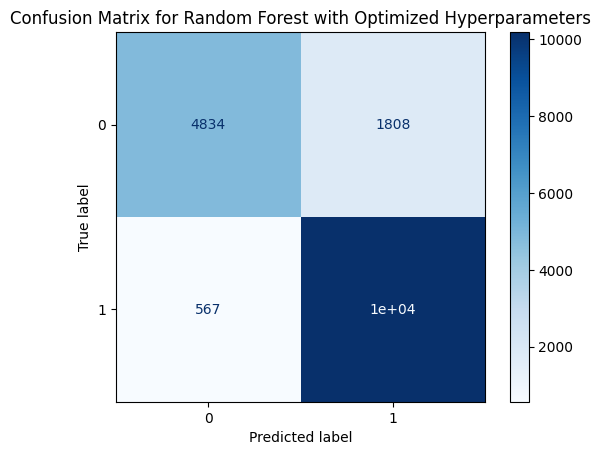

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rnd_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rnd_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Random Forest with Optimized Hyperparameters')
plt.show()

Above are the results of the confusion matrix for the Random Forest model, with 4834 unstable materials correctly classified as unstable, 1808 unstable materials being classified as stable, 567 stable materials being classifed as unstable, and ~10000 stable materials being classified as stable.

In [ ]:
precision_full = precision_score(y_test, y_pred, average='weighted')
recall_full = recall_score(y_test, y_pred, average='weighted')
f1_full = f1_score(y_test, y_pred, average='weighted')

print(f'Precision = {precision_full:.4f}')
print(f'Recall = {recall_full:.4f}')
print(f'F1 score = {f1_full:.4f}')

Precision = 0.8668
Recall = 0.8635
F1 score = 0.8602


From the precision score, 86.68% of the materials predicted to be stable were correct. From the recall score, the random forest was able to identify 86.35% of the stable materials as stable. The harmonic mean of the precision and recall scores is 0.8602, given by the F1 score.

Random Forest performs slightly better without optimized hyperparameters.

Gradient Boosting may be able to improve these scores, we will try that below:

In [ ]:
df = pd.read_csv('li_battery_dataset.csv')

#change true/false values to 0s and 1s
df['contains_transition_metal'] = df['contains_transition_metal'].astype(int)
df['is_semiconductor'] = df['is_semiconductor'].astype(int)

#add labels to the data
df["stability"] = (
    df["formation_energy_per_atom"] < 0
).astype(int)

#start by putting five features into features df
features = ['contains_transition_metal', 'energy_per_atom', 'band_gap', 'is_semiconductor', 'density', 'volume']

#convert data into dataframes and drop NANs
#this will ensure that the atoms label column is not included as it is non numerical
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=features, inplace=True)

#set up X and y values for training and testing of RF
X = df[features]
y= df['stability']

/tmp/ipykernel_10633/3127487840.py:1: DtypeWarning: Columns (13,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('li_battery_dataset.csv')


In [ ]:
#split data into 80% training data and 20% test again for gb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#start training gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=500, random_state=42)

In [ ]:
#evaluate GB on test data
y_pred = gb_clf.predict(X_test)

In [ ]:
importances = gb_clf.feature_importances_

print(importances)

[2.25943697e-02 6.06546622e-01 1.72483148e-01 3.11589409e-05
 1.53939075e-01 4.44056264e-02]


The feature importances are:

1. Energy per atom = 0.6065
2. Band Gap = 0.1725
3. Density = 0.1539
4. Volume = 0.0441
5. Contains transition metal = 0.0259
6. Semiconductor characteristics = 0.00003



The two most important features from gradient boosting are energy per atom and band gap.

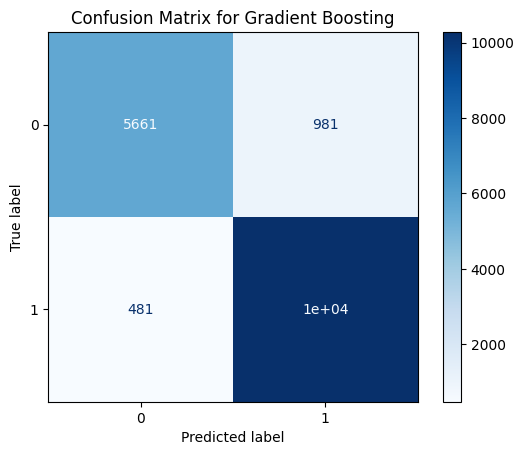

In [ ]:
y_pred = gb_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rnd_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Gradient Boosting')
plt.show()

Above are the results of the confusion matrix for the Gradient Boosting model, with 5661 unstable materials correctly classified as unstable, 981 unstable materials being classified as stable, 481 stable materials being classifed as unstable, and ~10,000 stable materials being classified as stable.

In [ ]:
precision_full = precision_score(y_test, y_pred, average='weighted')
recall_full = recall_score(y_test, y_pred, average='weighted')
f1_full = f1_score(y_test, y_pred, average='weighted')

print(f'Precision = {precision_full:.4f}')
print(f'Recall = {recall_full:.4f}')
print(f'F1 score = {f1_full:.4f}')

Precision = 0.9162
Recall = 0.9160
F1 score = 0.9153


From the precision score, 91.62% of the materials predicted to be stable were correct. From the recall score, the random forest was able to identify 91.60% of the stable materials as stable. The harmonic mean of the precision and recall scores is 0.9153, given by the F1 score.



We will again use GridSearchCV to see if we can improve these scores with optimized hyperparameters.

In [ ]:
#code provided from gemini for GridSearch
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
param_grid_rf = {
    'model__n_estimators': [25, 50],
    'model__max_depth': [2, 5],
    'model__max_leaf_nodes': [2, 5],
    'model__min_samples_split': [2, 3],
    'model__min_samples_leaf': [1]
}

# Create a pipeline for Random Forest with a StandardScaler
gb_pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(random_state=42)) # n_jobs=-1 to use all available cores
])

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='f1' as F1 score is the primary evaluation metric in the notebook
# n_jobs=-1 to use all available processors for faster computation
print("Starting GridSearchCV for Random Forest Classifier with *further reduced* iterations...")
grid_search_gb = GridSearchCV(estimator=gb_pipeline_gs, param_grid=param_grid_rf, cv=5, scoring='f1', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search_gb.fit(X_train, y_train)

print("GridSearchCV completed.")
# Print the best parameters and best score
print(f"Best parameters found for Random Forest: {grid_search_gb.best_params_}")
print(f"Best F1 score found for Random Forest: {grid_search_gb.best_score_:.4f}")

# Optionally, store the best estimator
best_gb_clf = grid_search_gb.best_estimator_

Starting GridSearchCV for Random Forest Classifier with *further reduced* iterations...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV completed.
Best parameters found for Random Forest: {'model__max_depth': 5, 'model__max_leaf_nodes': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best F1 score found for Random Forest: 0.9121


In [ ]:
#split data into 80% training data and 20% test again for gb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#start training gradient boosting with optimized hyperparameters
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=5, min_samples_leaf=1, min_samples_split=2, random_state=42)
gb_clf.fit(X_train, y_train)

GradientBoostingClassifier(max_depth=5, n_estimators=50, random_state=42)

In [ ]:
#evaluate GB on test data
y_pred = gb_clf.predict(X_test)

In [ ]:
importances = gb_clf.feature_importances_

print(importances)

[2.31859519e-02 6.38862604e-01 1.75192086e-01 2.46530919e-04
 1.27999856e-01 3.45129715e-02]


In order, feature importances are:

1. Energy per atom = 0.6389
2. Band gap = 0.1752
3. Density = 0.1280
4. Volume = 0.0345
5. Contains transition metal = 0.0232
6. Semiconductor characteristics = 0.0002

Two most important features from Gradient Boosting with optimized hyperparameters are energy per atom and band gap.

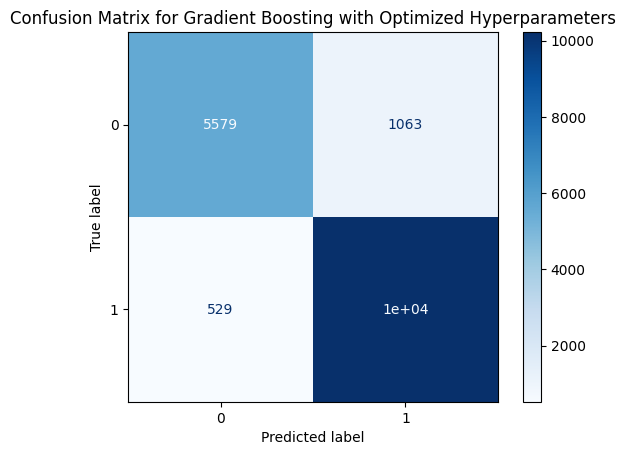

In [ ]:
y_pred = gb_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rnd_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Gradient Boosting with Optimized Hyperparameters')
plt.show()

Above are the results of the confusion matrix for the Gradient Boosting model, with 5579 unstable materials correctly classified as unstable, 1063 unstable materials being classified as stable, 529 stable materials being classifed as unstable, and ~10,000 stable materials being classified as stable.

In [ ]:
precision_full = precision_score(y_test, y_pred, average='weighted')
recall_full = recall_score(y_test, y_pred, average='weighted')
f1_full = f1_score(y_test, y_pred, average='weighted')

print(f'Precision = {precision_full:.4f}')
print(f'Recall = {recall_full:.4f}')
print(f'F1 score = {f1_full:.4f}')

Precision = 0.9087
Recall = 0.9085
F1 score = 0.9077


From the precision score, 90.87% of the materials predicted to be stable were correct. From the recall score, the random forest was able to identify 9085% of the stable materials as stable. The harmonic mean of the precision and recall scores is 0.9077, given by the F1 score. Gradient boosting also performs slightly worse with optimization of hyperparameters.



Let's try one last time with XG Boost to see if precision, recall, and accuracy scores can improve. XGBoost will incorperate L2 regulaization by creating simpler trees, which allows the model to train better on unseen data rather than just memorizing periously trained data when creating new trees.  

In [ ]:
pip install xgboost

In [ ]:
df = pd.read_csv('li_battery_dataset.csv')

#change true/false values to 0s and 1s
df['contains_transition_metal'] = df['contains_transition_metal'].astype(int)
df['is_semiconductor'] = df['is_semiconductor'].astype(int)

#add labels to the data
df["stability"] = (
    df["formation_energy_per_atom"] < 0
).astype(int)

#start by putting five features into features df
features = ['contains_transition_metal', 'energy_per_atom', 'band_gap', 'is_semiconductor', 'density', 'volume']

#convert data into dataframes and drop NANs
#this will ensure that the atoms label column is not included as it is non numerical
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=features, inplace=True)

#set up X and y values for training and testing of RF
X = df[features]
y= df['stability']

/tmp/ipykernel_10633/3127487840.py:1: DtypeWarning: Columns (13,15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('li_battery_dataset.csv')


In [ ]:
#split data into 80% training data and 20% test again for gb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(colsample_bytree = 0.7, max_depth = 7, n_estimators=300, learning_rate=0.2, random_state=42, subsample = 0.7)
xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#evaluate XGB on test data
y_pred = xgb_clf.predict(X_test)

In [ ]:
importances = xgb_clf.feature_importances_

print(importances)

[0.15861683 0.3389895  0.18052332 0.07378326 0.14680801 0.10127898]


In order, feature importances are:
 1. Energy per atom = 0. 3390
 2.  Band gap = 0.1805
 3. Contains transition metal = 0.1586
  4. Density = 0.1469
   5. Volume = 0.1013
6.  Semiconductor characteristics = 0.0738






The two most important features from XGBoost are energy per atom and band gap

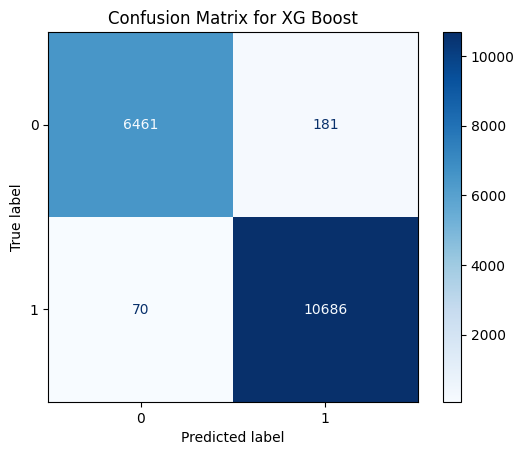

In [ ]:
y_pred = xgb_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rnd_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for XG Boost')
plt.show()

Above are the results of the confusion matrix for the XG Boost model, with 6461 unstable materials correctly classified as unstable, 181 unstable materials being classified as stable, 70 stable materials being classifed as unstable, and 10686 stable materials being classified as stable.

In [ ]:
precision_full = precision_score(y_test, y_pred, average='weighted')
recall_full = recall_score(y_test, y_pred, average='weighted')
f1_full = f1_score(y_test, y_pred, average='weighted')

print(f'Precision = {precision_full:.4f}')
print(f'Recall = {recall_full:.4f}')
print(f'F1 score = {f1_full:.4f}')

Precision = 0.9856
Recall = 0.9856
F1 score = 0.9855


From the precision score, 98.56% of the materials predicted to be stable were correct. From the recall score, the random forest was able to identify 98.56% of the stable materials as stable. The harmonic mean of the precision and recall scores is 0.9855, given by the F1 score.



Let's try optimizing hyperparameters for XGBoost with GridSearch:

In [ ]:
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier # Import XGBClassifier

# Define a parameter grid for XGBoostClassifier
param_grid_xgb = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.1, 0.2],
    'model__colsample_bytree': [0.6, 0.8],
    'model__subsample': [0.6, 0.8]
}

# Create a pipeline for XGBoost with a StandardScaler
xgb_pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(random_state=42)) # Use XGBClassifier
])

# Initialize GridSearchCV
# cv=5 for 5-fold cross-validation
# scoring='f1' as F1 score is the primary evaluation metric in the notebook
# n_jobs=-1 to use all available processors for faster computation
print("Starting GridSearchCV for XGBoost Classifier with *further reduced* iterations...")
grid_search_xgb = GridSearchCV(estimator=xgb_pipeline_gs, param_grid=param_grid_xgb, cv=5, scoring='f1', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

print("GridSearchCV completed.")
# Print the best parameters and best score
print(f"Best parameters found for XGBoost: {grid_search_xgb.best_params_}")
print(f"Best F1 score found for XGBoost: {grid_search_xgb.best_score_:.4f}")

# Optionally, store the best estimator
best_xgb_clf = grid_search_xgb.best_estimator_

Starting GridSearchCV for XGBoost Classifier with *further reduced* iterations...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
GridSearchCV completed.
Best parameters found for XGBoost: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.2, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best F1 score found for XGBoost: 0.9362


In [ ]:
#split data into 80% training data and 20% test again for gb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from xgboost import XGBClassifier

#update with optimized hyperparameters
xgb_clf = XGBClassifier(colsample_bytree=0.8, learning_rate=0.2, max_depth=5, n_estimators=100, subsample=0.8, random_state=42
)
xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#evaluate XGB on test data
y_pred = xgb_clf.predict(X_test)

In [ ]:
importances = xgb_clf.feature_importances_

print(importances)

[0.1338677  0.40888152 0.18400565 0.0585437  0.15070178 0.06399968]


In order, feature importances are:

 1. Energy per atom = 0.4089
 2. Band gap = 0.1840
 3. Density = 0.1507
 4. Contains transition metal = 0.1339
 5. Volume = 0.0640
 6. Semiconductor characteristics = 0.0585

 The two most important features for XG Boost with optimized hyperparameters are energy per atom and band gap.

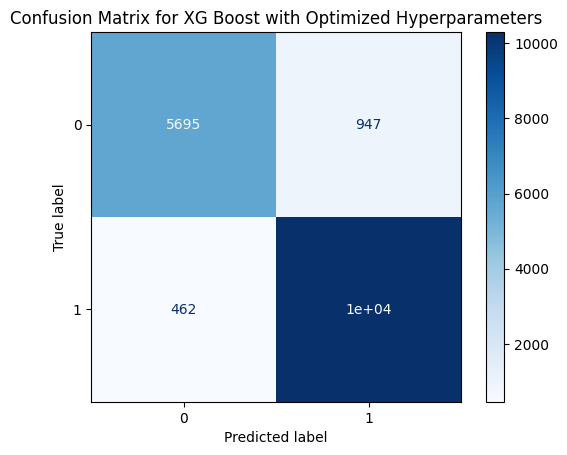

In [ ]:
y_pred = xgb_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rnd_clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for XG Boost with Optimized Hyperparameters')
plt.show()

Above are the results of the confusion matrix for the XG Boost model, with 5695 unstable materials correctly classified as unstable, 947 unstable materials being classified as stable, 462 stable materials being classifed as unstable, and ~10000 stable materials being classified as stable.

In [ ]:
precision_full = precision_score(y_test, y_pred, average='weighted')
recall_full = recall_score(y_test, y_pred, average='weighted')
f1_full = f1_score(y_test, y_pred, average='weighted')

print(f'Precision = {precision_full:.4f}')
print(f'Recall = {recall_full:.4f}')
print(f'F1 score = {f1_full:.4f}')

Precision = 0.9193
Recall = 0.9190
F1 score = 0.9184


From the precision score, 91.93% of the materials predicted to be stable were correct. From the recall score, the random forest was able to identify 91.90% of the stable materials as stable. The harmonic mean of the precision and recall scores is 0.9184, given by the F1 score.



Summarized Results of Tree Model Tests:
1. Random Forest
*   Most important features are energy per atom and density.
*   F1 score is 0.8789
2. Random Forest with optimized hyperparameters
*   Most important features are energy per atom and density.
*   F1 score is 0.8602
3. Gradient Boosting
*   Most important features are energy per atom and band gap.
* F1 score is 0.9153
4. Gradient Boosting with optimized hyperparameters
*   Most important features are energy per atom and band gap.
* F1 score is 0.9077
5. XG Boost
*   Most important features are energy per atom and band gap.
* F1 score is 0.9855
6. XG Boost with optimized hyperparameters
*   Most important features are energy per atom and band gap.
* F1 score is 0.9184





  

Gradient Boosting and XG Boost are both in agreement for the two most important features to classify stability being energy per atom and band gap. Because XG Boost without hyperparameter optimization had an F1 score of 0.9855, so the inference that energy per atom and band gap are the two most important features is supposed by a high F1 score.

We can make a scatter plots to see the distribution of the data in terms of stability:

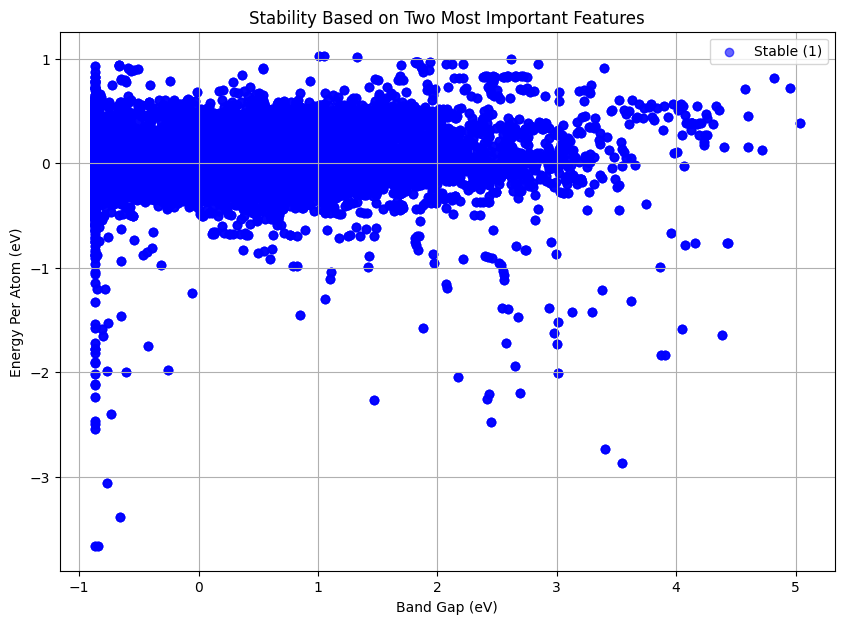

In [ ]:
plt.figure(figsize=(10, 7))

#separate data, labeling unstable as 0 and stable as 1
X_unstable = X[y == 0]
y_unstable = y[y == 0]
X_stable = X[y == 1]
y_stable = y[y == 1]

#plt.scatter(
 #   X_unstable['band_gap'],
   # X_unstable['energy_per_atom'],
    #c='red',
    #alpha=0.6,
    #label='Unstable (0)'
#)

plt.scatter(
    X_stable['band_gap'],
    X_stable['energy_per_atom'],
    c='blue',
    alpha=0.6,
    label='Stable (1)'
)

plt.xlabel("Band Gap (eV)")
plt.ylabel("Energy Per Atom (eV)")
plt.title("Stability Based on Two Most Important Features")
plt.legend()
plt.grid(True)
plt.show()

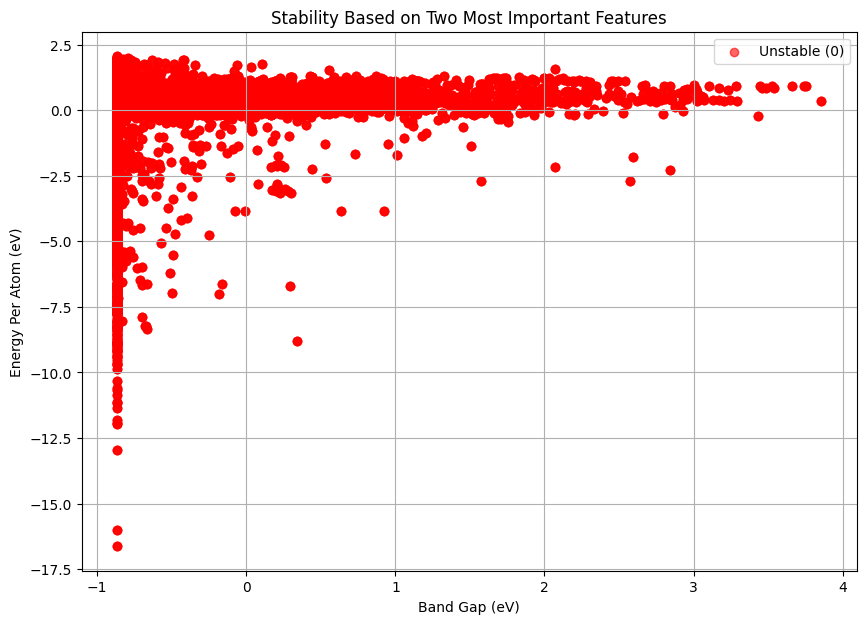

In [ ]:
plt.figure(figsize=(10, 7))

#separate data, labeling unstable as 0 and stable as 1
X_unstable = X[y == 0]
y_unstable = y[y == 0]
X_stable = X[y == 1]
y_stable = y[y == 1]

plt.scatter(
    X_unstable['band_gap'],
    X_unstable['energy_per_atom'],
    c='red',
    alpha=0.6,
    label='Unstable (0)'
)

#plt.scatter(
   # X_stable['band_gap'],
    #X_stable['energy_per_atom'],
   # c='blue',
   # alpha=0.6,
   # label='Stable (1)'
#)

plt.xlabel("Band Gap (eV)")
plt.ylabel("Energy Per Atom (eV)")
plt.title("Stability Based on Two Most Important Features")
plt.legend()
plt.grid(True)
plt.show()

We can plot the stable/unstable data on top of each other to see if there are any boundaries for band gap energy or energy per atom where a material is distinctly stable/unstable:

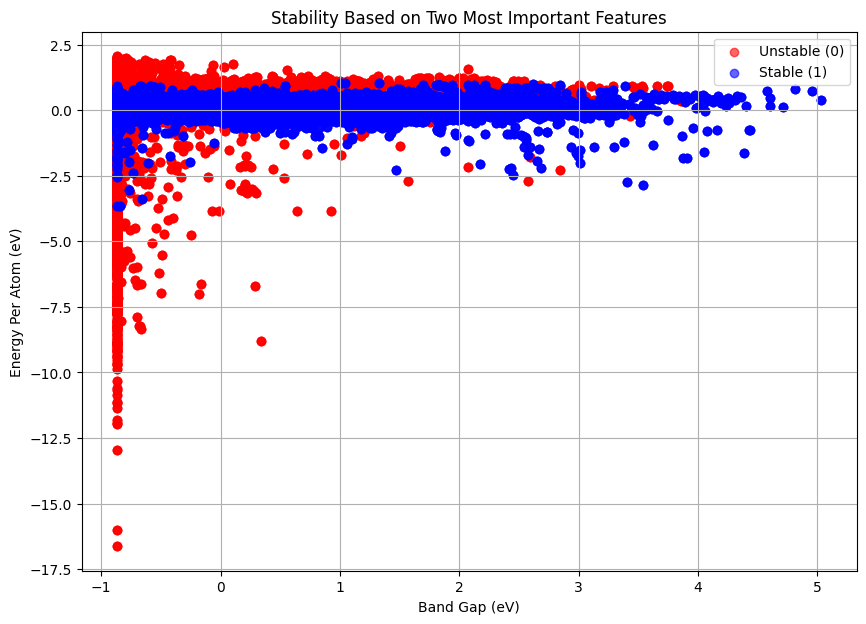

In [ ]:
plt.figure(figsize=(10, 7))

#separate data, labeling unstable as 0 and stable as 1
X_unstable = X[y == 0]
y_unstable = y[y == 0]
X_stable = X[y == 1]
y_stable = y[y == 1]

plt.scatter(
    X_unstable['band_gap'],
    X_unstable['energy_per_atom'],
    c='red',
    alpha=0.6,
    label='Unstable (0)'
)

plt.scatter(
    X_stable['band_gap'],
    X_stable['energy_per_atom'],
    c='blue',
    alpha=0.6,
    label='Stable (1)'
)

plt.xlabel("Band Gap (eV)")
plt.ylabel("Energy Per Atom (eV)")
plt.title("Stability Based on Two Most Important Features")
plt.legend()
plt.grid(True)
plt.show()

There is major overlap between stable and unstable points. This allows us to conclude that (at least for this particular dataset), decision trees are not enough to determine stability using only two features, and that employing a decision boundary would not be meaningful due to the data's poor separation. However, we can make some inferences based off of this plot:
1. Materials with energy per atom that is greater than 1 or less than -1 are likely to be unstable, with the exception of materials with energy per atom of ~2.5 being stable when band gap energy is greater than 3.  
2. This distrubution supports band gap energy being the second most important feature. There are stable materials for all values of band gap energy, unlike energy per atom.
3. Materials with band gap energy greater than 4 may be more likely to be stable.

Limitations of this project:
1. Using formation energy to add stability labels is not the most rigourous method of classifying stability. A better method would have been to use energy above hull to classify stability on a phase diagram, but this was outside of the scope of this project.
2. Proposed materials came from DFT, and some included negative densities in (g/cm3). Because of this, we can infer than some of the proposed materials would never actually exist.

Notes on workflow:

Initally, I excluded energy per atom, thinking it had a scalar relationship with formation energy per atom. After further investigation, I found that it does not, so I included it for the final version of this project.

When excluding energy per atom, the two most important features were semiconductor characterisitics and density, which resulted in data that fit into binary catogories, as semiconductor characterisitics were labeled with ones and zeros. This did not seem informative or meaningful, hence the decision to include an additional feature. This was plotted with logisitic regression, which created a linear decision boundary and had an accuracy of about 71%. It was not very informative.

I also did kernel SVM with energy per atom and band gap as the most important features. However, because the stable and unstable data sits on top of each other, the only insight from the Kernel SVM decision boundary was to find the numerical bounds for energy per atom and band gap that classifies materials as unstable.

I also wanted to compare all three decision tree models with no optimized hyperparameters and optimized hyperparameters. The plan was to use GridSearch to optimize hyperparameters, but this took over 30 minutes to run through over 300 iterations of testing different hyperparameters. In attempt to make this faster, I decreased the number of fits attempted which resulted in worse accuracy, precision, and F1 than no optimization at all. GridSearch is likely not worthwhile in the scope of this project, but I am leaving it in for comparision purposes and to examine the limitation of GridSearch by number of fits.